In [ ]:
import torch
from src.load.load_model import load_model

torch.set_float32_matmul_precision("high")

model, tokenizer = load_model("Qwen/Qwen2.5-1.5B-Instruct", torch_dtype="bfloat16")

In [ ]:
from src.activation_extractor import ActivationExtractor, ActivationManipulator

In [ ]:
# load direction and set

import os
import json

base_dir = "results"
model_name = model.name_or_path.split("/")[-1]
component = "residual_middle"
output_folder = os.path.join(base_dir, model_name, component.replace(" ", "_"))

direction_path = os.path.join(output_folder, "direction.pt")
metadata_path = os.path.join(output_folder, "metadata.json")

direction: torch.Tensor = torch.load(direction_path)

with open(metadata_path, "r") as f:
    metadata = json.load(f)

In [ ]:
# print some stuff regarding what we loaded

print("Model name:", model.name_or_path)
print("Direction shape:", direction.shape)
print("Layer path:", metadata["layer_path"])

# print metadata nicely
for k, v in metadata.items():
    print(f"{k}: {v}")

In [ ]:
layer_path = metadata["layer_path"]


def subtract_projection(activations: torch.Tensor) -> torch.Tensor:
    d = direction.to(activations.device, activations.dtype)
    v = d / d.norm()
    proj_scalars = activations @ v
    projection = proj_scalars.unsqueeze(-1) * v.unsqueeze(0).unsqueeze(0)
    return activations - projection


manipulator = ActivationManipulator(model, layer_path)
manipulator.set_manipulation(subtract_projection)

In [ ]:
from transformers import LlamaForCausalLM

In [ ]:
import lm_eval
from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM

bench_model = HFLM(model, tokenizer=tokenizer, batch_size=40, dtype=torch.bfloat16)

tasks = [
    "hellaswag",  # Commonsense reasoning
    "mmlu_zero_shot",  # Broad factual knowledge
    "lambada_openai",  # Language modeling / fluency
    "boolq",  # Reading comprehension
    "arc_easy",  # Symbolic reasoning
    "gsm8k",  # Mathematical reasoning
    "openbookqa",  # Knowledge application
    "rte",  # Logical entailment
]

stress_tasks = [
    "truthfulqa_mc",  # Adversarial truthfulness
    "toxigen",  # Toxicity control
    "realtoxicityprompts",  # Refusal robustness
    "crows_pairs_english",  # Implicit bias
    "hendrycks_ethics",  # Ethical reasoning
]

with manipulator.capture():
    results_ablated = evaluator.simple_evaluate(
        model=bench_model,
        tasks=["hellaswag", "mmlu", "gsm8k"],
        batch_size=80,
        device="cuda:0",
    )

    print(results_ablated["results"])

results_vanilla = evaluator.simple_evaluate(
    model=bench_model,
    tasks=["hellaswag", "mmlu", "gsm8k"],
    batch_size=40,
    device="cuda:0",
)

print(results_vanilla["results"])

In [1]:
import numpy as np

# original = results_vanilla["results"]

# results of Llama3.2 3B
original = {'gsm8k': {'alias': 'gsm8k', 'exact_match,strict-match': np.float64(0.5905989385898408), 'exact_match_stderr,strict-match': 0.013544504071244514, 'exact_match,flexible-extract': np.float64(0.6785443517816527), 'exact_match_stderr,flexible-extract': 0.012864471384836705}, 'hellaswag': {'alias': 'hellaswag', 'acc,none': 0.5324636526588329, 'acc_stderr,none': 0.004979252954976992, 'acc_norm,none': 0.7155945030870344, 'acc_norm_stderr,none': 0.004502088287470376}, 'mmlu': {'acc,none': 0.6222760290556901, 'acc_stderr,none': np.float64(0.0039383751813421635), 'alias': 'mmlu'}, 'mmlu_humanities': {'acc,none': 0.6112646121147716, 'acc_stderr,none': np.float64(0.006913974398449268), 'alias': ' - humanities'}, 'mmlu_formal_logic': {'alias': '  - formal_logic', 'acc,none': 0.42857142857142855, 'acc_stderr,none': 0.04426266681379905}, 'mmlu_high_school_european_history': {'alias': '  - high_school_european_history', 'acc,none': 0.7393939393939394, 'acc_stderr,none': 0.03427743175816526}, 'mmlu_high_school_us_history': {'alias': '  - high_school_us_history', 'acc,none': 0.7254901960784313, 'acc_stderr,none': 0.03132179803083291}, 'mmlu_high_school_world_history': {'alias': '  - high_school_world_history', 'acc,none': 0.7974683544303798, 'acc_stderr,none': 0.02616056824660147}, 'mmlu_international_law': {'alias': '  - international_law', 'acc,none': 0.7272727272727273, 'acc_stderr,none': 0.040655781409087086}, 'mmlu_jurisprudence': {'alias': '  - jurisprudence', 'acc,none': 0.6666666666666666, 'acc_stderr,none': 0.04557239513497755}, 'mmlu_logical_fallacies': {'alias': '  - logical_fallacies', 'acc,none': 0.7484662576687117, 'acc_stderr,none': 0.03408997886857529}, 'mmlu_moral_disputes': {'alias': '  - moral_disputes', 'acc,none': 0.6820809248554913, 'acc_stderr,none': 0.025070713719153193}, 'mmlu_moral_scenarios': {'alias': '  - moral_scenarios', 'acc,none': 0.6256983240223464, 'acc_stderr,none': 0.016185444179457154}, 'mmlu_philosophy': {'alias': '  - philosophy', 'acc,none': 0.6720257234726688, 'acc_stderr,none': 0.02666441088693758}, 'mmlu_prehistory': {'alias': '  - prehistory', 'acc,none': 0.6635802469135802, 'acc_stderr,none': 0.026289734945952926}, 'mmlu_professional_law': {'alias': '  - professional_law', 'acc,none': 0.47196870925684486, 'acc_stderr,none': 0.012750151802922528}, 'mmlu_world_religions': {'alias': '  - world_religions', 'acc,none': 0.8011695906432749, 'acc_stderr,none': 0.030611116557432514}, 'mmlu_other': {'acc,none': 0.683617637592533, 'acc_stderr,none': np.float64(0.008036382904340346), 'alias': ' - other'}, 'mmlu_business_ethics': {'alias': '  - business_ethics', 'acc,none': 0.6, 'acc_stderr,none': 0.0492365963917331}, 'mmlu_clinical_knowledge': {'alias': '  - clinical_knowledge', 'acc,none': 0.6641509433962264, 'acc_stderr,none': 0.029067220146644885}, 'mmlu_college_medicine': {'alias': '  - college_medicine', 'acc,none': 0.6416184971098265, 'acc_stderr,none': 0.0365634365335316}, 'mmlu_global_facts': {'alias': '  - global_facts', 'acc,none': 0.35, 'acc_stderr,none': 0.04793724854411023}, 'mmlu_human_aging': {'alias': '  - human_aging', 'acc,none': 0.6412556053811659, 'acc_stderr,none': 0.032190792004199886}, 'mmlu_management': {'alias': '  - management', 'acc,none': 0.8058252427184466, 'acc_stderr,none': 0.03916667762822582}, 'mmlu_marketing': {'alias': '  - marketing', 'acc,none': 0.8632478632478633, 'acc_stderr,none': 0.022509033937077844}, 'mmlu_medical_genetics': {'alias': '  - medical_genetics', 'acc,none': 0.77, 'acc_stderr,none': 0.042295258468165065}, 'mmlu_miscellaneous': {'alias': '  - miscellaneous', 'acc,none': 0.7777777777777778, 'acc_stderr,none': 0.014866821664709668}, 'mmlu_nutrition': {'alias': '  - nutrition', 'acc,none': 0.6797385620915033, 'acc_stderr,none': 0.02671611838015683}, 'mmlu_professional_accounting': {'alias': '  - professional_accounting', 'acc,none': 0.46099290780141844, 'acc_stderr,none': 0.029736592526424455}, 'mmlu_professional_medicine': {'alias': '  - professional_medicine', 'acc,none': 0.7647058823529411, 'acc_stderr,none': 0.025767252010855998}, 'mmlu_virology': {'alias': '  - virology', 'acc,none': 0.4939759036144578, 'acc_stderr,none': 0.03892212195333041}, 'mmlu_social_sciences': {'acc,none': 0.683132921676958, 'acc_stderr,none': np.float64(0.00823462699311999), 'alias': ' - social sciences'}, 'mmlu_econometrics': {'alias': '  - econometrics', 'acc,none': 0.4298245614035088, 'acc_stderr,none': 0.04657047260594963}, 'mmlu_high_school_geography': {'alias': '  - high_school_geography', 'acc,none': 0.7323232323232324, 'acc_stderr,none': 0.031544498882702825}, 'mmlu_high_school_government_and_politics': {'alias': '  - high_school_government_and_politics', 'acc,none': 0.7668393782383419, 'acc_stderr,none': 0.03051611137147603}, 'mmlu_high_school_macroeconomics': {'alias': '  - high_school_macroeconomics', 'acc,none': 0.6, 'acc_stderr,none': 0.02483881198803324}, 'mmlu_high_school_microeconomics': {'alias': '  - high_school_microeconomics', 'acc,none': 0.6386554621848739, 'acc_stderr,none': 0.031204691225150072}, 'mmlu_high_school_psychology': {'alias': '  - high_school_psychology', 'acc,none': 0.7834862385321101, 'acc_stderr,none': 0.017658710594443204}, 'mmlu_human_sexuality': {'alias': '  - human_sexuality', 'acc,none': 0.7175572519083969, 'acc_stderr,none': 0.039484061257683584}, 'mmlu_professional_psychology': {'alias': '  - professional_psychology', 'acc,none': 0.6094771241830066, 'acc_stderr,none': 0.01973700899809455}, 'mmlu_public_relations': {'alias': '  - public_relations', 'acc,none': 0.6363636363636364, 'acc_stderr,none': 0.04607582090719978}, 'mmlu_security_studies': {'alias': '  - security_studies', 'acc,none': 0.6775510204081633, 'acc_stderr,none': 0.029923100563683976}, 'mmlu_sociology': {'alias': '  - sociology', 'acc,none': 0.7960199004975125, 'acc_stderr,none': 0.02849317624532607}, 'mmlu_us_foreign_policy': {'alias': '  - us_foreign_policy', 'acc,none': 0.84, 'acc_stderr,none': 0.03684529491774706}, 'mmlu_stem': {'acc,none': 0.518870916587377, 'acc_stderr,none': np.float64(0.008596990187694949), 'alias': ' - stem'}, 'mmlu_abstract_algebra': {'alias': '  - abstract_algebra', 'acc,none': 0.33, 'acc_stderr,none': 0.04725815626252609}, 'mmlu_anatomy': {'alias': '  - anatomy', 'acc,none': 0.6518518518518519, 'acc_stderr,none': 0.04115324610336956}, 'mmlu_astronomy': {'alias': '  - astronomy', 'acc,none': 0.7105263157894737, 'acc_stderr,none': 0.03690677986137281}, 'mmlu_college_biology': {'alias': '  - college_biology', 'acc,none': 0.7222222222222222, 'acc_stderr,none': 0.037455547914624555}, 'mmlu_college_chemistry': {'alias': '  - college_chemistry', 'acc,none': 0.41, 'acc_stderr,none': 0.04943110704237104}, 'mmlu_college_computer_science': {'alias': '  - college_computer_science', 'acc,none': 0.54, 'acc_stderr,none': 0.05009082659620331}, 'mmlu_college_mathematics': {'alias': '  - college_mathematics', 'acc,none': 0.29, 'acc_stderr,none': 0.045604802157206865}, 'mmlu_college_physics': {'alias': '  - college_physics', 'acc,none': 0.39215686274509803, 'acc_stderr,none': 0.04858083574266346}, 'mmlu_computer_security': {'alias': '  - computer_security', 'acc,none': 0.67, 'acc_stderr,none': 0.04725815626252609}, 'mmlu_conceptual_physics': {'alias': '  - conceptual_physics', 'acc,none': 0.4978723404255319, 'acc_stderr,none': 0.03268572658667493}, 'mmlu_electrical_engineering': {'alias': '  - electrical_engineering', 'acc,none': 0.6, 'acc_stderr,none': 0.040824829046386304}, 'mmlu_elementary_mathematics': {'alias': '  - elementary_mathematics', 'acc,none': 0.43915343915343913, 'acc_stderr,none': 0.025559920550531027}, 'mmlu_high_school_biology': {'alias': '  - high_school_biology', 'acc,none': 0.7129032258064516, 'acc_stderr,none': 0.02573654274559456}, 'mmlu_high_school_chemistry': {'alias': '  - high_school_chemistry', 'acc,none': 0.541871921182266, 'acc_stderr,none': 0.035056301407857406}, 'mmlu_high_school_computer_science': {'alias': '  - high_school_computer_science', 'acc,none': 0.68, 'acc_stderr,none': 0.046882617226215076}, 'mmlu_high_school_mathematics': {'alias': '  - high_school_mathematics', 'acc,none': 0.362962962962963, 'acc_stderr,none': 0.02931820364520686}, 'mmlu_high_school_physics': {'alias': '  - high_school_physics', 'acc,none': 0.37748344370860926, 'acc_stderr,none': 0.03958027231121572}, 'mmlu_high_school_statistics': {'alias': '  - high_school_statistics', 'acc,none': 0.44907407407407407, 'acc_stderr,none': 0.033922384053216154}, 'mmlu_machine_learning': {'alias': '  - machine_learning', 'acc,none': 0.45535714285714285, 'acc_stderr,none': 0.04726835553719097}}

In [2]:
# ablated = results_ablated["results"]

# results of Llama3.2 3B
ablated = {'gsm8k': {'alias': 'gsm8k', 'exact_match,strict-match': np.float64(0.5959059893858984), 'exact_match_stderr,strict-match': 0.013516752972721719, 'exact_match,flexible-extract': np.float64(0.6739954510993177), 'exact_match_stderr,flexible-extract': 0.01291167564568285}, 'hellaswag': {'alias': 'hellaswag', 'acc,none': 0.5320653256323441, 'acc_stderr,none': 0.004979510001776503, 'acc_norm,none': 0.7173869747062338, 'acc_norm_stderr,none': 0.004493495872000464}, 'mmlu': {'acc,none': 0.6220623842757442, 'acc_stderr,none': np.float64(0.003936787558160331), 'alias': 'mmlu'}, 'mmlu_humanities': {'acc,none': 0.6106269925611052, 'acc_stderr,none': np.float64(0.006905550799665276), 'alias': ' - humanities'}, 'mmlu_formal_logic': {'alias': '  - formal_logic', 'acc,none': 0.40476190476190477, 'acc_stderr,none': 0.043902592653775656}, 'mmlu_high_school_european_history': {'alias': '  - high_school_european_history', 'acc,none': 0.7393939393939394, 'acc_stderr,none': 0.03427743175816526}, 'mmlu_high_school_us_history': {'alias': '  - high_school_us_history', 'acc,none': 0.7352941176470589, 'acc_stderr,none': 0.030964517926923372}, 'mmlu_high_school_world_history': {'alias': '  - high_school_world_history', 'acc,none': 0.8016877637130801, 'acc_stderr,none': 0.02595502084162111}, 'mmlu_international_law': {'alias': '  - international_law', 'acc,none': 0.7272727272727273, 'acc_stderr,none': 0.040655781409087086}, 'mmlu_jurisprudence': {'alias': '  - jurisprudence', 'acc,none': 0.6666666666666666, 'acc_stderr,none': 0.04557239513497755}, 'mmlu_logical_fallacies': {'alias': '  - logical_fallacies', 'acc,none': 0.7484662576687117, 'acc_stderr,none': 0.03408997886857529}, 'mmlu_moral_disputes': {'alias': '  - moral_disputes', 'acc,none': 0.6763005780346821, 'acc_stderr,none': 0.02519018132760835}, 'mmlu_moral_scenarios': {'alias': '  - moral_scenarios', 'acc,none': 0.6256983240223464, 'acc_stderr,none': 0.016185444179457154}, 'mmlu_philosophy': {'alias': '  - philosophy', 'acc,none': 0.6784565916398714, 'acc_stderr,none': 0.026527724079528824}, 'mmlu_prehistory': {'alias': '  - prehistory', 'acc,none': 0.6666666666666666, 'acc_stderr,none': 0.026229649178821125}, 'mmlu_professional_law': {'alias': '  - professional_law', 'acc,none': 0.46936114732724904, 'acc_stderr,none': 0.012746237711716587}, 'mmlu_world_religions': {'alias': '  - world_religions', 'acc,none': 0.8011695906432749, 'acc_stderr,none': 0.030611116557432514}, 'mmlu_other': {'acc,none': 0.6852269069842292, 'acc_stderr,none': np.float64(0.00802395861681177), 'alias': ' - other'}, 'mmlu_business_ethics': {'alias': '  - business_ethics', 'acc,none': 0.58, 'acc_stderr,none': 0.04960449637488582}, 'mmlu_clinical_knowledge': {'alias': '  - clinical_knowledge', 'acc,none': 0.6566037735849056, 'acc_stderr,none': 0.02922452646912477}, 'mmlu_college_medicine': {'alias': '  - college_medicine', 'acc,none': 0.6416184971098265, 'acc_stderr,none': 0.0365634365335316}, 'mmlu_global_facts': {'alias': '  - global_facts', 'acc,none': 0.34, 'acc_stderr,none': 0.04760952285695233}, 'mmlu_human_aging': {'alias': '  - human_aging', 'acc,none': 0.6367713004484304, 'acc_stderr,none': 0.03227790442850494}, 'mmlu_management': {'alias': '  - management', 'acc,none': 0.8058252427184466, 'acc_stderr,none': 0.03916667762822582}, 'mmlu_marketing': {'alias': '  - marketing', 'acc,none': 0.8675213675213675, 'acc_stderr,none': 0.022209309073165668}, 'mmlu_medical_genetics': {'alias': '  - medical_genetics', 'acc,none': 0.77, 'acc_stderr,none': 0.042295258468165065}, 'mmlu_miscellaneous': {'alias': '  - miscellaneous', 'acc,none': 0.7854406130268199, 'acc_stderr,none': 0.01468003395689333}, 'mmlu_nutrition': {'alias': '  - nutrition', 'acc,none': 0.6764705882352942, 'acc_stderr,none': 0.026787453111906473}, 'mmlu_professional_accounting': {'alias': '  - professional_accounting', 'acc,none': 0.48226950354609927, 'acc_stderr,none': 0.02980873964223769}, 'mmlu_professional_medicine': {'alias': '  - professional_medicine', 'acc,none': 0.7610294117647058, 'acc_stderr,none': 0.025905280644893044}, 'mmlu_virology': {'alias': '  - virology', 'acc,none': 0.4939759036144578, 'acc_stderr,none': 0.03892212195333041}, 'mmlu_social_sciences': {'acc,none': 0.6824829379265518, 'acc_stderr,none': np.float64(0.008242253648200169), 'alias': ' - social sciences'}, 'mmlu_econometrics': {'alias': '  - econometrics', 'acc,none': 0.4473684210526316, 'acc_stderr,none': 0.04677473004491205}, 'mmlu_high_school_geography': {'alias': '  - high_school_geography', 'acc,none': 0.7323232323232324, 'acc_stderr,none': 0.031544498882702825}, 'mmlu_high_school_government_and_politics': {'alias': '  - high_school_government_and_politics', 'acc,none': 0.7616580310880829, 'acc_stderr,none': 0.030748905363909895}, 'mmlu_high_school_macroeconomics': {'alias': '  - high_school_macroeconomics', 'acc,none': 0.5974358974358974, 'acc_stderr,none': 0.02486499515976774}, 'mmlu_high_school_microeconomics': {'alias': '  - high_school_microeconomics', 'acc,none': 0.6386554621848739, 'acc_stderr,none': 0.031204691225150072}, 'mmlu_high_school_psychology': {'alias': '  - high_school_psychology', 'acc,none': 0.7853211009174312, 'acc_stderr,none': 0.01760430414925655}, 'mmlu_human_sexuality': {'alias': '  - human_sexuality', 'acc,none': 0.7175572519083969, 'acc_stderr,none': 0.039484061257683584}, 'mmlu_professional_psychology': {'alias': '  - professional_psychology', 'acc,none': 0.6062091503267973, 'acc_stderr,none': 0.01976621199107302}, 'mmlu_public_relations': {'alias': '  - public_relations', 'acc,none': 0.6363636363636364, 'acc_stderr,none': 0.04607582090719978}, 'mmlu_security_studies': {'alias': '  - security_studies', 'acc,none': 0.673469387755102, 'acc_stderr,none': 0.030021056238440355}, 'mmlu_sociology': {'alias': '  - sociology', 'acc,none': 0.7960199004975125, 'acc_stderr,none': 0.02849317624532607}, 'mmlu_us_foreign_policy': {'alias': '  - us_foreign_policy', 'acc,none': 0.84, 'acc_stderr,none': 0.03684529491774706}, 'mmlu_stem': {'acc,none': 0.5179194418014589, 'acc_stderr,none': np.float64(0.008601977659316275), 'alias': ' - stem'}, 'mmlu_abstract_algebra': {'alias': '  - abstract_algebra', 'acc,none': 0.34, 'acc_stderr,none': 0.04760952285695233}, 'mmlu_anatomy': {'alias': '  - anatomy', 'acc,none': 0.6592592592592592, 'acc_stderr,none': 0.04094376269996792}, 'mmlu_astronomy': {'alias': '  - astronomy', 'acc,none': 0.7105263157894737, 'acc_stderr,none': 0.03690677986137281}, 'mmlu_college_biology': {'alias': '  - college_biology', 'acc,none': 0.7152777777777778, 'acc_stderr,none': 0.037738099906869334}, 'mmlu_college_chemistry': {'alias': '  - college_chemistry', 'acc,none': 0.4, 'acc_stderr,none': 0.0492365963917331}, 'mmlu_college_computer_science': {'alias': '  - college_computer_science', 'acc,none': 0.54, 'acc_stderr,none': 0.05009082659620331}, 'mmlu_college_mathematics': {'alias': '  - college_mathematics', 'acc,none': 0.31, 'acc_stderr,none': 0.04648231987117317}, 'mmlu_college_physics': {'alias': '  - college_physics', 'acc,none': 0.37254901960784315, 'acc_stderr,none': 0.048108401480826374}, 'mmlu_computer_security': {'alias': '  - computer_security', 'acc,none': 0.68, 'acc_stderr,none': 0.046882617226215076}, 'mmlu_conceptual_physics': {'alias': '  - conceptual_physics', 'acc,none': 0.5063829787234042, 'acc_stderr,none': 0.032683358999363386}, 'mmlu_electrical_engineering': {'alias': '  - electrical_engineering', 'acc,none': 0.593103448275862, 'acc_stderr,none': 0.040937939812662354}, 'mmlu_elementary_mathematics': {'alias': '  - elementary_mathematics', 'acc,none': 0.4312169312169312, 'acc_stderr,none': 0.025506481698138284}, 'mmlu_high_school_biology': {'alias': '  - high_school_biology', 'acc,none': 0.7064516129032258, 'acc_stderr,none': 0.02590608702131934}, 'mmlu_high_school_chemistry': {'alias': '  - high_school_chemistry', 'acc,none': 0.5467980295566502, 'acc_stderr,none': 0.035025446508458756}, 'mmlu_high_school_computer_science': {'alias': '  - high_school_computer_science', 'acc,none': 0.68, 'acc_stderr,none': 0.046882617226215076}, 'mmlu_high_school_mathematics': {'alias': '  - high_school_mathematics', 'acc,none': 0.36666666666666664, 'acc_stderr,none': 0.029381620726464993}, 'mmlu_high_school_physics': {'alias': '  - high_school_physics', 'acc,none': 0.37748344370860926, 'acc_stderr,none': 0.03958027231121572}, 'mmlu_high_school_statistics': {'alias': '  - high_school_statistics', 'acc,none': 0.44907407407407407, 'acc_stderr,none': 0.033922384053216154}, 'mmlu_machine_learning': {'alias': '  - machine_learning', 'acc,none': 0.4375, 'acc_stderr,none': 0.04708567521880525}}

In [3]:
# and now compare both results

for bench_name in original.keys():
    orig_bench = original[bench_name]
    ablated_bench = ablated[bench_name]
    
    print(f"\n{'='*80}")
    print(f"Benchmark: {bench_name}")
    print(f"{'='*80}")
    
    maxlen = max([len(subkey) for subkey in orig_bench.keys()])
    for subkey in orig_bench.keys():
        if isinstance(orig_bench[subkey], str):
            continue 
        delta = ablated_bench[subkey] - orig_bench[subkey]
        print(f"  {subkey:{maxlen}s} | Original: {orig_bench[subkey]:8.4f} | Ablated: {ablated_bench[subkey]:8.4f} | Delta: {delta:+8.4f}")



Benchmark: gsm8k
  exact_match,strict-match            | Original:   0.5906 | Ablated:   0.5959 | Delta:  +0.0053
  exact_match_stderr,strict-match     | Original:   0.0135 | Ablated:   0.0135 | Delta:  -0.0000
  exact_match,flexible-extract        | Original:   0.6785 | Ablated:   0.6740 | Delta:  -0.0045
  exact_match_stderr,flexible-extract | Original:   0.0129 | Ablated:   0.0129 | Delta:  +0.0000

Benchmark: hellaswag
  acc,none             | Original:   0.5325 | Ablated:   0.5321 | Delta:  -0.0004
  acc_stderr,none      | Original:   0.0050 | Ablated:   0.0050 | Delta:  +0.0000
  acc_norm,none        | Original:   0.7156 | Ablated:   0.7174 | Delta:  +0.0018
  acc_norm_stderr,none | Original:   0.0045 | Ablated:   0.0045 | Delta:  -0.0000

Benchmark: mmlu
  acc,none        | Original:   0.6223 | Ablated:   0.6221 | Delta:  -0.0002
  acc_stderr,none | Original:   0.0039 | Ablated:   0.0039 | Delta:  -0.0000

Benchmark: mmlu_humanities
  acc,none        | Original:   0.6113 | Abla

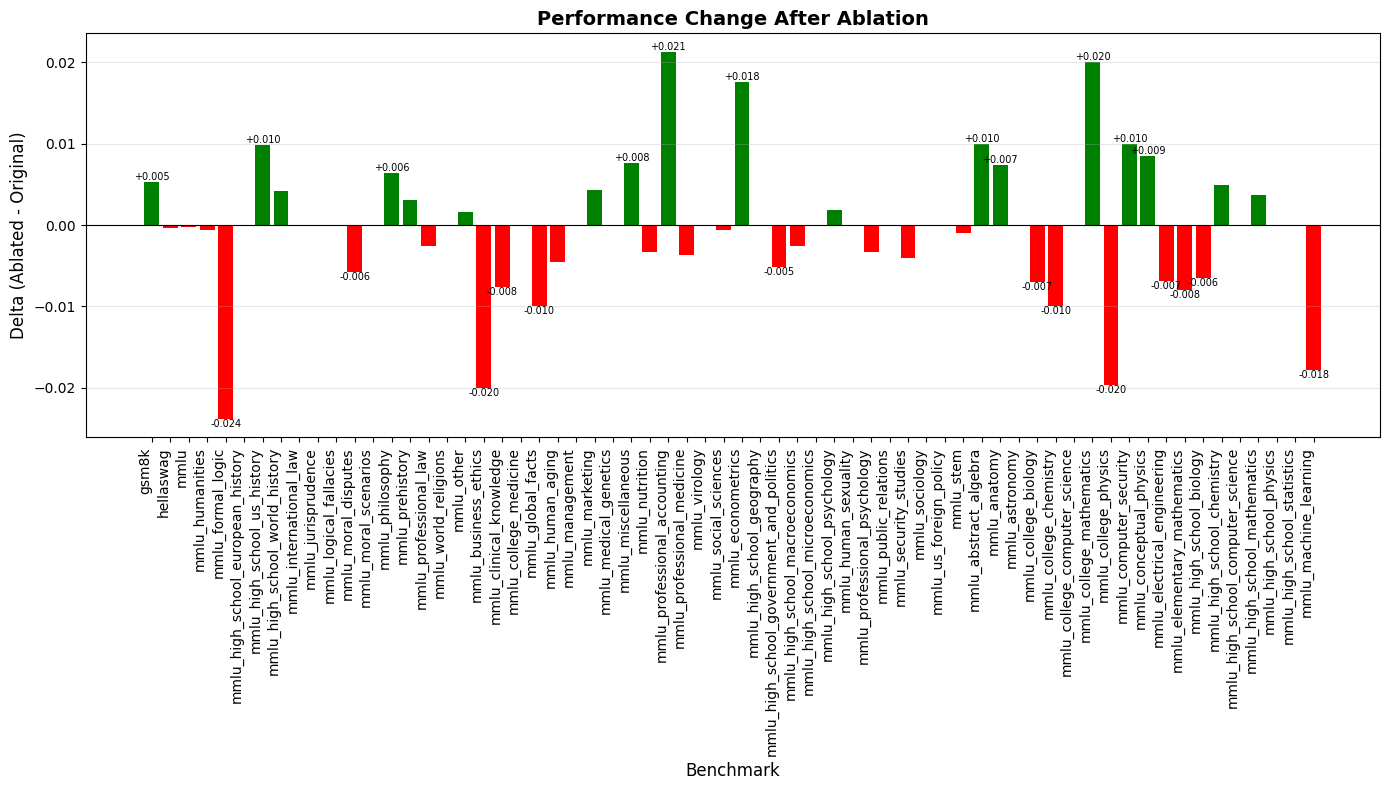


Delta values (excluding stderr metrics):
gsm8k                                             : +0.005307
hellaswag                                         : -0.000398
mmlu                                              : -0.000214
mmlu_humanities                                   : -0.000638
mmlu_formal_logic                                 : -0.023810
mmlu_high_school_european_history                 : +0.000000
mmlu_high_school_us_history                       : +0.009804
mmlu_high_school_world_history                    : +0.004219
mmlu_international_law                            : +0.000000
mmlu_jurisprudence                                : +0.000000
mmlu_logical_fallacies                            : +0.000000
mmlu_moral_disputes                               : -0.005780
mmlu_moral_scenarios                              : +0.000000
mmlu_philosophy                                   : +0.006431
mmlu_prehistory                                   : +0.003086
mmlu_professional_law       

In [4]:
import matplotlib.pyplot as plt

# Extract deltas for all benchmarks (excluding stderr metrics)
benchmark_names = []
deltas = []

for bench_name in original.keys():
    orig_bench = original[bench_name]
    ablated_bench = ablated[bench_name]
    
    # Get the first non-stderr, non-alias metric
    for metric_name, metric_value in orig_bench.items():
        if 'stderr' not in metric_name and metric_name != 'alias' and not isinstance(metric_value, str):
            delta = ablated_bench[metric_name] - orig_bench[metric_name]
            benchmark_names.append(bench_name)
            deltas.append(delta)
            break  # Only take the first valid metric per benchmark

# Create the barplot
fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.bar(benchmark_names, deltas, color=['red' if d < 0 else 'green' for d in deltas])

# Customize the plot
ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('Delta (Ablated - Original)', fontsize=12)
ax.set_title('Performance Change After Ablation', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')

# Add value labels on bars (only for significant deltas)
for bar, delta in zip(bars, deltas):
    height = bar.get_height()
    if abs(delta) > 0.005:  # Only show label if delta is significant
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{delta:+.3f}',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=7, rotation=0)

plt.tight_layout()
plt.show()

print("\nDelta values (excluding stderr metrics):")
for name, delta in zip(benchmark_names, deltas):
    print(f"{name:50s}: {delta:+.6f}")
